# How well do jobs and skills pay for Top 5 roles in SEA?

## Methodology
1. Evaluate median salary for top 5 jobs
2. Find median salary per skill for top 5 jobs
3. Visualize for highest paying skills and most demanded skills

## Import Libraries and Dataset

In [21]:
#Turn off warning notification
import warnings
warnings.filterwarnings("ignore")

import datasets
datasets.logging.set_verbosity_error()

In [22]:
# Import Libraries
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from matplotlib.ticker import PercentFormatter

#Load dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df.job_posted_date = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## Salary Distribution by Job Title

Filter our data to only include salary values from Southeast Asia.

In [23]:
# Countries belong to Southeast Asia
countries = ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia' , 'Myanmar'
             , 'Philippines', 'Singapore', 'Thailand', 'East Timor', 'Vietnam']

In [31]:
# Skill count per month for top 5 jobs
df_SEA = df[(df['job_country'].isin(countries))].copy()

# Calculating the median salary
median_salary = df_SEA['salary_year_avg'].median()

# Filling the missing values with the median salary to keep the DataFrame intact
df_SEA['salary_year_avg'] = df_SEA['salary_year_avg'].fillna(median_salary)

Create a list of the main job_titles in our dataset and filter our dataframe to only contain these job titles.

In [25]:
job_titles = df_SEA['job_title_short'].value_counts().head(5).index

# Filter the df for top 5 job title:
df_SEA_top5 = df_SEA[df_SEA['job_title_short'].isin(job_titles)]

# Order the job titles by median salary:
job_order = df_SEA_top5.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=False).index

job_order 

Index(['Data Engineer', 'Data Scientist', 'Data Analyst', 'Business Analyst',
       'Software Engineer'],
      dtype='str', name='job_title_short')

## Plot Salary Distributions

Plot the top 5 job titles salary distributions using a box plot.

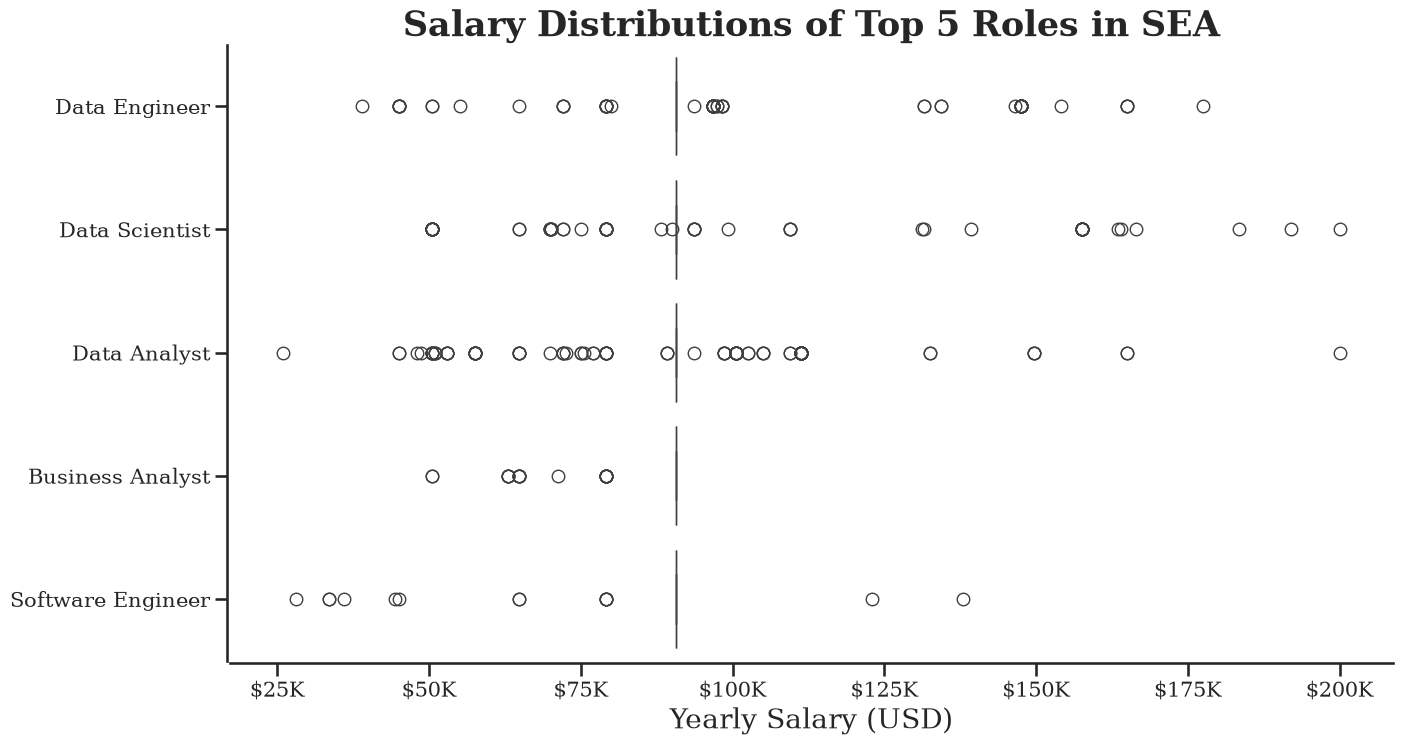

In [32]:
fig, ax = plt.subplots(figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'tab10'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.7)

sns.boxplot(
            data=df_SEA
            , y = 'job_title_short'
            , x = 'salary_year_avg'
            , order = job_order)

sns.despine(offset=2)

plt.title(
            'Salary Distributions of Top 5 Roles in SEA'
            , fontdict={'fontsize': 25, 'fontweight': 'bold'})

plt.xlabel(
            'Yearly Salary (USD)'
            , fontdict={'fontsize': 20}
            , loc = 'center')

plt.ylabel(
            ''
            , fontdict={'fontsize': 20})

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000):,}K'))
plt.gca().tick_params(axis='x', labelsize = 15)
plt.gca().tick_params(axis='y', labelsize = 15)

plt.show()

##  Determine The Highest Paid Skills and Most Demanded Skills

Gets the top ten highest-paying skills for top 5 roles by calculating the mean salary for each skill listed in the df_SEA DataFrame. It groups the data by job_skills, computes the mean salary, sorts these values in descending order by mean, ant the selects the top 10 skills. Then, it's formatted into a new DataFrame (df_SEA_top_pay) with reset index method and renamed salary column labeled by 'mean_salary'.

In [38]:
df_SEA = df_SEA.explode('job_skills')

df_SEA

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
25,Senior Data Analyst,"Senior Officer, Data Analyst, GTO",Singapore,via BeBee Singapore,Full-time,False,Singapore,2023-06-23 13:56:10,True,False,Singapore,NaN,90670.0,NaN,United Overseas Bank,sql,{'programming': ['sql']}
44,Data Scientist,Binance Accelerator Program - Data Scientist (...,Singapore,via LinkedIn,Contractor,False,Singapore,2023-04-12 13:53:26,False,False,Singapore,NaN,90670.0,NaN,Binance,python,"{'programming': ['python', 'java', 'scala']}"
44,Data Scientist,Binance Accelerator Program - Data Scientist (...,Singapore,via LinkedIn,Contractor,False,Singapore,2023-04-12 13:53:26,False,False,Singapore,NaN,90670.0,NaN,Binance,java,"{'programming': ['python', 'java', 'scala']}"
44,Data Scientist,Binance Accelerator Program - Data Scientist (...,Singapore,via LinkedIn,Contractor,False,Singapore,2023-04-12 13:53:26,False,False,Singapore,NaN,90670.0,NaN,Binance,scala,"{'programming': ['python', 'java', 'scala']}"
47,Senior Data Engineer,Senior Data Engineering,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-05-06 14:15:59,True,False,Malaysia,NaN,90670.0,NaN,Agensi Pekerjaan BTC Sdn Bhd,sql,"{'analyst_tools': ['power bi', 'microstrategy'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,90670.0,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,kubernetes,"{'os': ['linux', 'unix'], 'other': ['kubernete..."
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,90670.0,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,docker,"{'os': ['linux', 'unix'], 'other': ['kubernete..."
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,90670.0,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,ansible,"{'os': ['linux', 'unix'], 'other': ['kubernete..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,90670.0,NaN,Lendlease Corporation,powerpoint,"{'analyst_tools': ['powerpoint', 'excel']}"


In [40]:
df_SEA_top_pay = df_SEA.groupby('job_skills')['salary_year_avg'].agg(['count', 'mean']).sort_values(by = 'mean', ascending = False)

df_SEA_top_pay = df_SEA_top_pay.head(10)

df_SEA_top_pay

,count,mean
job_skills,,
mxnet,68,93385.588235
kotlin,130,91544.307692
asana,40,91511.500000
fastapi,110,91242.004545
zoom,72,91091.319444
slack,111,91061.801802
puppet,148,91053.986486
chef,150,91048.866667
pytorch,1516,91012.154354


Calculates the count and mean salary for each skill in df_SEA. It groups the data by job_skills, then aggregatges it to find the count and mean salary for each skill, and sort the results continuously by count in descending order by count. Finally, it re-sorts this subset by mean salary in descending order.

In [44]:
df_SEA_top_skills = df_SEA.groupby('job_skills')['salary_year_avg'].agg(['count', 'mean']).sort_values(by = 'count', ascending = False)

df_SEA_top_skills = df_SEA_top_skills.head(10).sort_values(by='mean', ascending=False)

df_SEA_top_skills

,count,mean
job_skills,,
spark,6928,90881.020280
python,22884,90789.856363
java,6164,90769.846528
power bi,7391,90766.682046
azure,6263,90765.197429
sql,25104,90749.842714
aws,7155,90712.198183
tableau,9836,90703.483072
r,7696,90689.030210


Creates two horizontal bar charts:

1. Displays the highest paid skills
2. Shows the most in demand skills

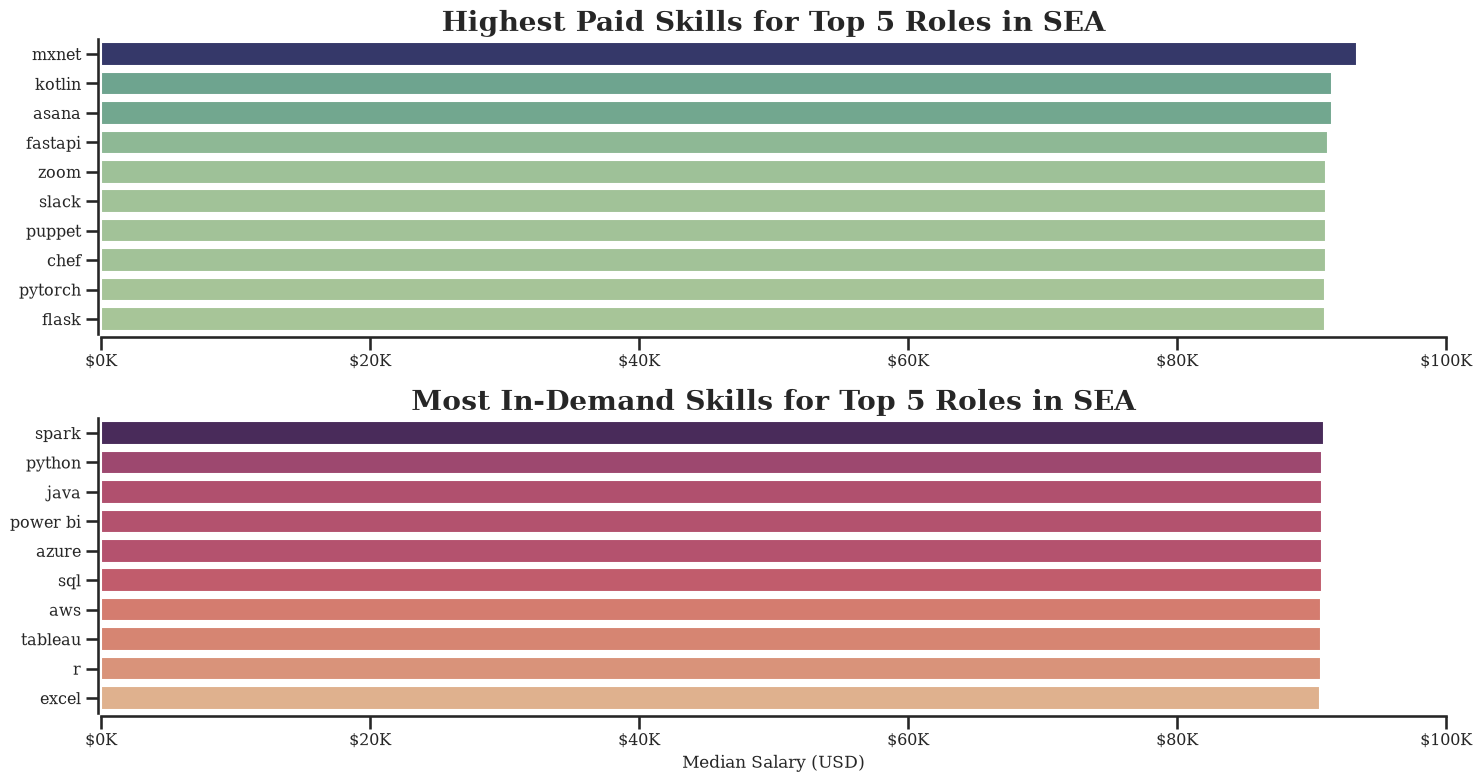

In [70]:
fig, ax = plt.subplots(
                        2
                        , 1
                        , figsize = (15, 8))

# Top 10 Highest Paid Skills for The Top 5 Roles

sns.set_theme(
                style='ticks'
                , palette = 'crest'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.7)

sns.barplot(
            data = df_SEA_top_pay
            , x = 'mean'
            , y = df_SEA_top_pay.index
            , hue = 'mean'
            , ax = ax[0]
            , palette='crest'
            , legend=False)

sns.despine(offset=2)

ax[0].set_title(
                'Highest Paid Skills for Top 5 Roles in SEA'
                , fontsize = 20
                , fontweight = 'bold')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_xlim(0,100000)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000):,}K'))


sns.barplot(
            data = df_SEA_top_skills
            , x = 'mean'
            , y = df_SEA_top_skills.index
            , hue = 'mean'
            , ax = ax[1]
            , palette='flare'
            , legend=False)

ax[1].set_title(
                'Most In-Demand Skills for Top 5 Roles in SEA'
                , fontsize = 20
                , fontweight = 'bold')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()